# Digit recognizer
Programa creado para clasificar imágenes 28x28 de dígitos según su etiqueta 0-9 con algoritmos de Inteligencia Artificial

# Análisis del dataset

In [34]:
"""
IMPORTANTE:
En Github no se encuentran los archivos de 'train.csv' y 'test.csv' (pesan mucho)
Sin embargo, si que tenemos una carpeta ZIP con esos archivos. Para ejecutar el código,
se deben extraer primero (dentro de la carpeta)
"""

import pandas as pd

raw_train = pd.read_csv("data/train.csv")
raw_test = pd.read_csv("data/test.csv")

In [2]:
raw_train.describe()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
count,42000.000000,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,...,42000.000000,42000.000000,42000.000000,42000.00000,42000.000000,42000.000000,42000.0,42000.0,42000.0,42000.0
mean,4.456643,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.219286,0.117095,0.059024,0.02019,0.017238,0.002857,0.0,0.0,0.0,0.0
std,2.887730,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.312890,4.633819,3.274488,1.75987,1.894498,0.414264,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.00000,254.000000,62.000000,0.0,0.0,0.0,0.0


In [3]:
train_nulls = raw_train.isnull().sum().values
test_nulls = raw_test.isnull().sum().values

print(f"Número de valores nulos en train: {train_nulls.sum()}")
print(f"Número de valores nulos en test: {test_nulls.sum()}")

Número de valores nulos en train: 0
Número de valores nulos en test: 0


Vemos en la documentación (https://www.kaggle.com/competitions/digit-recognizer) que las imágenes tienen 28x28 píxeles en escala de grises, con valores entre 0-255

Vamos a crear una función que muestre por pantalla una imagen específica del dataset para visualizarla mejor

In [4]:
# Como parece que vamos a usar mucho este código, añado una función que convierta una fila de los datos en un array 2D
def crearMatriz(df, i):
    img = df.iloc[i]

    # Quitamos la columna 'label' si existe
    title = f"Image #{i}"
    label = None
    if "label" in img.index:
        title += f" (Number {img["label"]})"
        label = img["label"]
        # Convertimos el data series de pandas a un array de numpy
        # y eliminamos el valor "label" (ubicado en la primera posición)
        img = img.values[1:]
    else:
        img = img.values

    # Ahora, transformamos el array en un array 2D, 28x28
    img = img.reshape((28, 28))
    
    return img, label, title

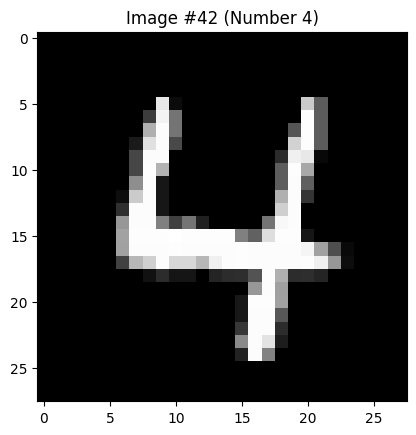

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def mostrarImagen(df, i):
    """
    df: dataframe
    i: integer
    """
    img, label, title = crearMatriz(df, i)

    plt.imshow(img, cmap="gray", vmin=0, vmax=255)
    plt.title(label=title)
    plt.show()

mostrarImagen(raw_train, 42)

Creamos una función para visualizar todos los datos de un dataset [simplemente para probar que números aparecen]

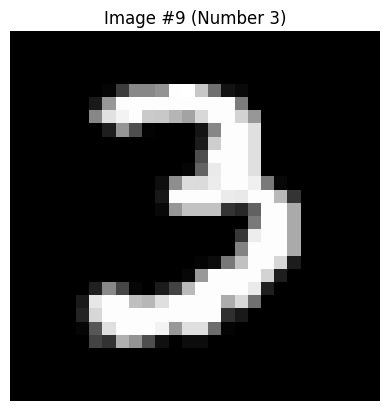

In [6]:
from IPython.display import clear_output


def mostrarImgsDataframe(df, inicio, fin):
    # Activa modo interactivo
    plt.ion()

    for i in range(inicio, fin):
        # Usamos el código anterior para dibujar la matriz 2D
        img, label, title = crearMatriz(df, i)

        plt.imshow(img, cmap="gray", vmin=0, vmax=255)
        plt.title(label=title)
        plt.axis("off")

        # Refrescamos la ventana y esperamos N segundos
        plt.pause(0.02)

        # Borramos el output anterior
        clear_output(wait=True)
        plt.show()


mostrarImgsDataframe(raw_train, 0, 10)

# Creación de las matrices de 'números ideales'

Con el fin de evaluar a que label corresponde cada matriz, vamos a comprobar a que 'número ideal' se parece más dicha matriz. Estos 'números ideales' serán calculados como la media de los números de ese 'label'; es decir, se superponen los números uno encima de otro y se calcula cual es el 'número promedio' o 'número ideal'

In [24]:
# Función para mostrar las imágenes de esos números ideales. La usaremos más adelante
def mostrarNumsIdeales(nums, figsize=(7, 7)):
    """
    nums: list de números ideales
    """

    fig, axs = plt.subplots(nrows=2, ncols=5, figsize=figsize)
    # Convertimos la matriz 2D de sublots en una lista 1D
    axs = axs.flatten()

    for i in range(len(nums)):
        img = nums[i]
        title = f"Número {i}"

        axs[i].set_title(title)
        axs[i].imshow(img, cmap="gray", vmin=0, vmax=255)
        axs[i].axis("off")

    plt.show()

In [25]:
# --- Para el conjunto 'train', se crea un número ideal para cada label 0-9 ---

# Creamos unas matrices para guardar la suma/superposición de matrices
nums_ideales = []
for i in range(10):
    matriz = np.zeros((28, 28))
    nums_ideales.append(matriz)

for i in range(len(raw_train)):
    img, label, _ = crearMatriz(raw_train, i)
    
    # Sumamos los valores de cada pixel a su matriz correspondiente
    nums_ideales[label] += img

# Ahora, necesitamos normalizar los valores entre 0 y 255
for i in range(len(nums_ideales)):
    valor_maximo = nums_ideales[i].max()
    if valor_maximo == 0:
        raise ValueError("La matriz está vacía")

    # El valor máximo tendrá un valor de (255 / valor_maximo) * valor_minimo = 255
    # Y el mínimo (255 / valor_maximo) * 0 = 0
    nums_ideales[i] = np.multiply(255 / valor_maximo, nums_ideales[i])



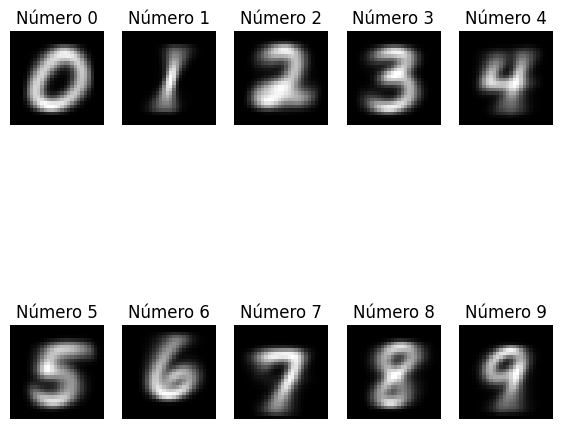

In [26]:
# Podemos visualizar el resultado usando las funciones anteriores
mostrarNumsIdeales(nums_ideales)